In [5]:
import pandas as pd

static = pd.read_csv("../data/static_baseline.csv")
adaptive = pd.read_csv("../data/chunk_timings.csv")

print(static.head())
print(adaptive.head())


   chunk_id  chunk_size  time_ms
0         1      100000   1.3880
1         2      100000   1.3868
2         3      100000   1.5311
3         4      100000   3.0760
4         5      100000   1.4369
   chunk_id  chunk_size  time_ms  variance
0         1       50000   1.3849  0.000000
1         2       50000   3.2209  0.000000
2         3       50000   1.9181  0.000000
3         4       50000   1.6155  0.000000
4         5       50000   1.5936  0.434879


In [6]:
static_mean = static["time_ms"].mean()
print("Static mean time (ms):", static_mean)


Static mean time (ms): 1.6623039999999998


In [7]:
adaptive_mean = adaptive["time_ms"].mean()
print("Adaptive mean time (ms):", adaptive_mean)


Adaptive mean time (ms): 1.7599511111111115


In [8]:
static_max = static["time_ms"].max()
print("Static max time (ms):", static_max)
adaptive_max = adaptive["time_ms"].max()
print("Adaptive max time (ms):", adaptive_max)


Static max time (ms): 3.076
Adaptive max time (ms): 3.2209


In [9]:
VAR_THRESHOLD = 0.2

max_run = 0
current_run = 0

for v in adaptive["variance"]:
    if v > VAR_THRESHOLD:
        current_run += 1
        max_run = max(max_run, current_run)
    else:
        current_run = 0

print("Adaptive max sustained variance window:", max_run)


Adaptive max sustained variance window: 2


In [10]:
WINDOW = 5

static_variances = []
times = static["time_ms"].values

for i in range(len(times)):
    if i < WINDOW - 1:
        static_variances.append(0.0)
    else:
        window = times[i-WINDOW+1:i+1]
        mean = window.mean()
        var = ((window - mean) ** 2).mean()
        static_variances.append(var)

static["variance"] = static_variances


In [11]:
VAR_THRESHOLD = 0.2

max_run_static = 0
current_run = 0

for v in static["variance"]:
    if v > VAR_THRESHOLD:
        current_run += 1
        max_run_static = max(max_run_static, current_run)
    else:
        current_run = 0

print("Static max sustained variance window:", max_run_static)


Static max sustained variance window: 5


In [12]:
VAR_THRESHOLD = 0.2

static_events = (static["variance"] > VAR_THRESHOLD).sum()
adaptive_events = (adaptive["variance"] > VAR_THRESHOLD).sum()

print("Static high-variance events:", static_events)
print("Adaptive high-variance events:", adaptive_events)


Static high-variance events: 9
Adaptive high-variance events: 2


In [13]:
import matplotlib.pyplot as plt


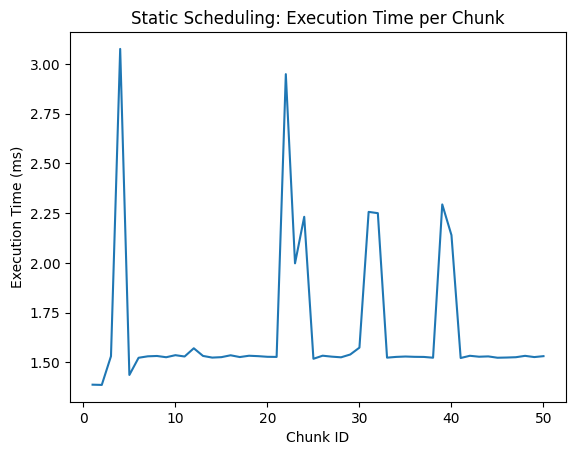

In [14]:
plt.figure()
plt.plot(static["chunk_id"], static["time_ms"])
plt.xlabel("Chunk ID")
plt.ylabel("Execution Time (ms)")
plt.title("Static Scheduling: Execution Time per Chunk")
plt.show()


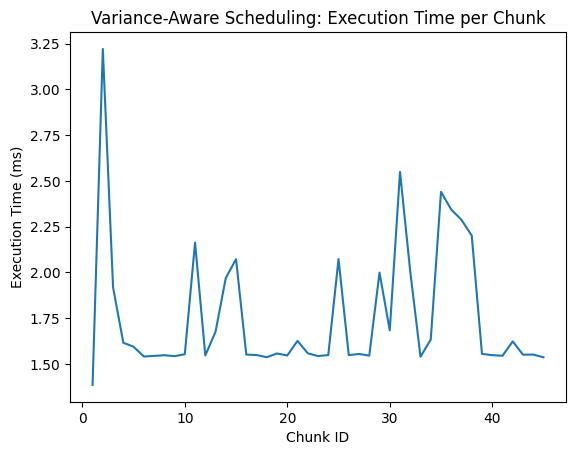

In [15]:
plt.figure()
plt.plot(adaptive["chunk_id"], adaptive["time_ms"])
plt.xlabel("Chunk ID")
plt.ylabel("Execution Time (ms)")
plt.title("Variance-Aware Scheduling: Execution Time per Chunk")
plt.show()


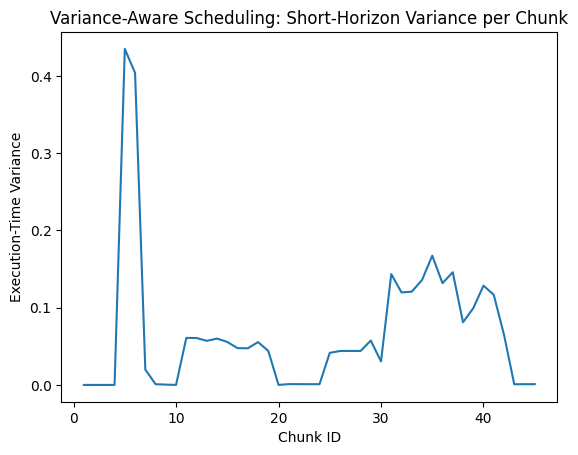

In [16]:
plt.figure()
plt.plot(adaptive["chunk_id"], adaptive["variance"])
plt.xlabel("Chunk ID")
plt.ylabel("Execution-Time Variance")
plt.title("Variance-Aware Scheduling: Short-Horizon Variance per Chunk")
plt.show()


In [1]:
import pandas as pd
import glob
import os

data_path = r"C:\Users\arjun\variance_gpu_project\data"

# Load all static trials
static_files = sorted(glob.glob(os.path.join(data_path, "static_trial_*.csv")))
static_trials = []

for file in static_files:
    df = pd.read_csv(file)
    df["trial"] = os.path.basename(file)
    static_trials.append(df)

# Load all adaptive trials
adaptive_files = sorted(glob.glob(os.path.join(data_path, "adaptive_trial_*.csv")))
adaptive_trials = []

for file in adaptive_files:
    df = pd.read_csv(file)
    df["trial"] = os.path.basename(file)
    adaptive_trials.append(df)

static_all = pd.concat(static_trials, ignore_index=True)
adaptive_all = pd.concat(adaptive_trials, ignore_index=True)

print("Static trials:", len(static_files))
print("Adaptive trials:", len(adaptive_files))

print("\nStatic total measurements:", len(static_all))
print("Adaptive total measurements:", len(adaptive_all))

Static trials: 5
Adaptive trials: 5

Static total measurements: 250
Adaptive total measurements: 2805


C:\Users\arjun\AppData\Local\Temp\ipykernel_6888\728793737.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
print("STATIC CHUNKS PER TRIAL")
print(static_all.groupby("trial").size())

print("\nADAPTIVE CHUNKS PER TRIAL")
print(adaptive_all.groupby("trial").size())


STATIC CHUNKS PER TRIAL
trial
static_trial_1.csv    50
static_trial_2.csv    50
static_trial_3.csv    50
static_trial_4.csv    50
static_trial_5.csv    50
dtype: int64

ADAPTIVE CHUNKS PER TRIAL
trial
adaptive_trial_1.csv    931
adaptive_trial_2.csv    365
adaptive_trial_3.csv    139
adaptive_trial_4.csv    447
adaptive_trial_5.csv    923
dtype: int64


In [3]:
adaptive_summary = adaptive_all.groupby("trial").agg(
    chunks=("chunk_id", "count"),
    avg_chunk_size=("chunk_size", "mean"),
    min_chunk_size=("chunk_size", "min"),
    max_chunk_size=("chunk_size", "max"),
    avg_time_ms=("time_ms", "mean")
)

print(adaptive_summary)

                      chunks  avg_chunk_size  min_chunk_size  max_chunk_size  \
trial                                                                          
adaptive_trial_1.csv     931     5370.569280            1506           73348   
adaptive_trial_2.csv     365    13698.630137            2890          202902   
adaptive_trial_3.csv     139    35971.223022            3125          163125   
adaptive_trial_4.csv     447    11185.682327            2706           86353   
adaptive_trial_5.csv     923     5417.118093            2603           83320   

                      avg_time_ms  
trial                              
adaptive_trial_1.csv     2.662520  
adaptive_trial_2.csv     2.610172  
adaptive_trial_3.csv     2.429732  
adaptive_trial_4.csv     2.541427  
adaptive_trial_5.csv     2.593945  


In [4]:
static_trial_summary = static_all.groupby("trial").agg(
    total_time_ms=("time_ms", "sum"),
    mean_chunk_time_ms=("time_ms", "mean"),
    std_chunk_time_ms=("time_ms", "std"),
    max_chunk_time_ms=("time_ms", "max")
)

adaptive_trial_summary = adaptive_all.groupby("trial").agg(
    total_time_ms=("time_ms", "sum"),
    mean_chunk_time_ms=("time_ms", "mean"),
    std_chunk_time_ms=("time_ms", "std"),
    max_chunk_time_ms=("time_ms", "max")
)

print("STATIC")
print(static_trial_summary)

print("\nADAPTIVE")
print(adaptive_trial_summary)

STATIC
                    total_time_ms  mean_chunk_time_ms  std_chunk_time_ms  \
trial                                                                      
static_trial_1.csv       124.3585            2.487170           0.547138   
static_trial_2.csv       121.3468            2.426936           0.712751   
static_trial_3.csv       128.6704            2.573408           0.617981   
static_trial_4.csv       124.0384            2.480768           0.605463   
static_trial_5.csv       118.8563            2.377126           0.533030   

                    max_chunk_time_ms  
trial                                  
static_trial_1.csv             3.6542  
static_trial_2.csv             5.2362  
static_trial_3.csv             3.7047  
static_trial_4.csv             3.4412  
static_trial_5.csv             3.4907  

ADAPTIVE
                      total_time_ms  mean_chunk_time_ms  std_chunk_time_ms  \
trial                                                                        
adaptive_trial

In [5]:
import glob
import os
import pandas as pd

# Load tuned adaptive trials
tuned_files = sorted(
    glob.glob(os.path.join(data_path, "adaptive_tuned_trial_*.csv"))
)

tuned_trials = []

for file in tuned_files:
    df = pd.read_csv(file)
    df["trial"] = os.path.basename(file)
    tuned_trials.append(df)

tuned_all = pd.concat(tuned_trials, ignore_index=True)

print("Tuned adaptive trials:", len(tuned_files))
print("Total measurements:", len(tuned_all))

print("\nChunks per trial:")
print(tuned_all.groupby("trial").size())

Tuned adaptive trials: 5
Total measurements: 234

Chunks per trial:
trial
adaptive_tuned_trial_1.csv    43
adaptive_tuned_trial_2.csv    44
adaptive_tuned_trial_3.csv    45
adaptive_tuned_trial_4.csv    47
adaptive_tuned_trial_5.csv    55
dtype: int64


In [6]:
tuned_summary = tuned_all.groupby("trial").agg(
    chunks=("chunk_id", "count"),
    total_time_ms=("time_ms", "sum"),
    mean_chunk_time_ms=("time_ms", "mean"),
    std_chunk_time_ms=("time_ms", "std"),
    max_chunk_time_ms=("time_ms", "max"),
    avg_chunk_size=("chunk_size", "mean"),
    min_chunk_size=("chunk_size", "min"),
    max_chunk_size=("chunk_size", "max")
)

print(tuned_summary)


                            chunks  total_time_ms  mean_chunk_time_ms  \
trial                                                                   
adaptive_tuned_trial_1.csv      43        99.3520            2.310512   
adaptive_tuned_trial_2.csv      44       115.1258            2.616495   
adaptive_tuned_trial_3.csv      45       114.1723            2.537162   
adaptive_tuned_trial_4.csv      47       119.7333            2.547517   
adaptive_tuned_trial_5.csv      55       138.4115            2.516573   

                            std_chunk_time_ms  max_chunk_time_ms  \
trial                                                              
adaptive_tuned_trial_1.csv           0.468446             3.3942   
adaptive_tuned_trial_2.csv           0.562677             3.7864   
adaptive_tuned_trial_3.csv           0.484118             3.4618   
adaptive_tuned_trial_4.csv           0.624797             3.7313   
adaptive_tuned_trial_5.csv           0.692880             3.7783   

           

In [7]:
comparison = pd.DataFrame({
    "Static": [
        static_trial_summary["total_time_ms"].mean(),
        static_trial_summary["std_chunk_time_ms"].mean(),
        static_trial_summary["max_chunk_time_ms"].mean()
    ],
    "Original Adaptive": [
        adaptive_trial_summary["total_time_ms"].mean(),
        adaptive_trial_summary["std_chunk_time_ms"].mean(),
        adaptive_trial_summary["max_chunk_time_ms"].mean()
    ],
    "Tuned Adaptive": [
        tuned_summary["total_time_ms"].mean(),
        tuned_summary["std_chunk_time_ms"].mean(),
        tuned_summary["max_chunk_time_ms"].mean()
    ]
}, index=[
    "Average Total Runtime (ms)",
    "Average Chunk Time Std Dev (ms)",
    "Average Maximum Chunk Time (ms)"
])

print(comparison)

                                     Static  Original Adaptive  Tuned Adaptive
Average Total Runtime (ms)       123.454080        1459.896040      117.358980
Average Chunk Time Std Dev (ms)    0.603273           0.651571        0.566584
Average Maximum Chunk Time (ms)    3.905400           4.555860        3.630400


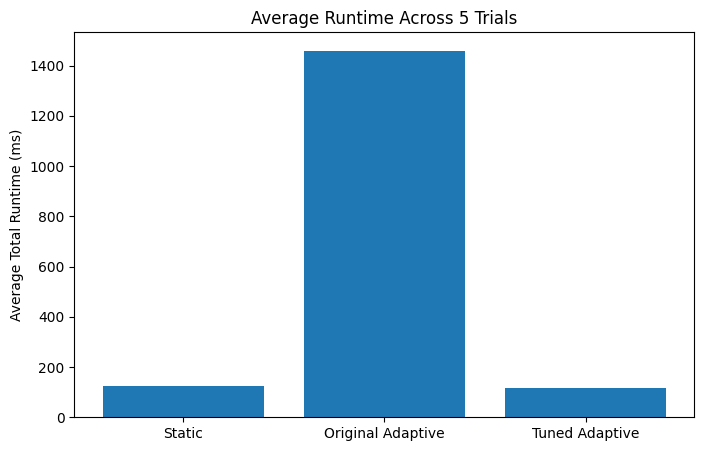

In [13]:
import matplotlib.pyplot as plt

methods = ["Static", "Original Adaptive", "Tuned Adaptive"]

avg_runtime = [
    static_trial_summary["total_time_ms"].mean(),
    adaptive_trial_summary["total_time_ms"].mean(),
    tuned_summary["total_time_ms"].mean()
]

plt.figure(figsize=(8, 5))
plt.bar(methods, avg_runtime)
plt.ylabel("Average Total Runtime (ms)")
plt.title("Average Runtime Across 5 Trials")
plt.savefig("../results/runtime_all_methods.png", dpi=300, bbox_inches="tight")
plt.show()

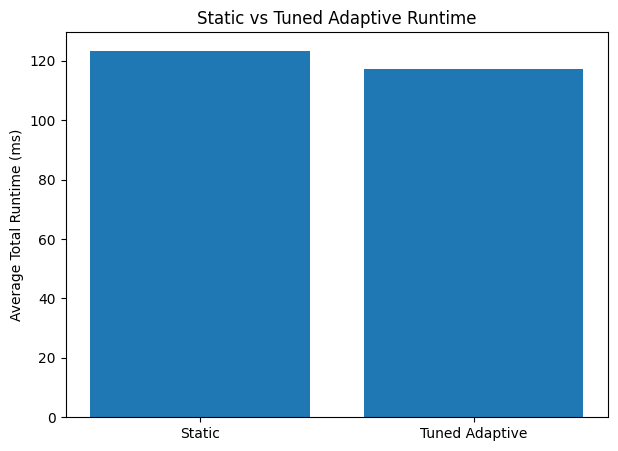

In [14]:
methods = ["Static", "Tuned Adaptive"]

avg_runtime = [
    static_trial_summary["total_time_ms"].mean(),
    tuned_summary["total_time_ms"].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(methods, avg_runtime)
plt.ylabel("Average Total Runtime (ms)")
plt.title("Static vs Tuned Adaptive Runtime")
plt.savefig("../results/runtime_static_vs_tuned.png", dpi=300, bbox_inches="tight")
plt.show()

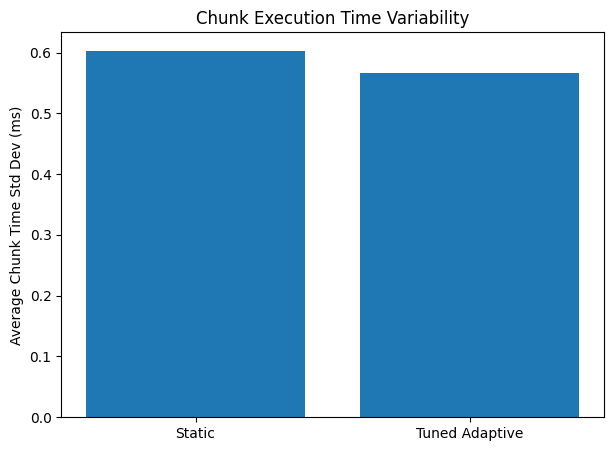

In [15]:
methods = ["Static", "Tuned Adaptive"]

std_dev = [
    static_trial_summary["std_chunk_time_ms"].mean(),
    tuned_summary["std_chunk_time_ms"].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(methods, std_dev)
plt.ylabel("Average Chunk Time Std Dev (ms)")
plt.title("Chunk Execution Time Variability")
plt.savefig("../results/timing_variability.png", dpi=300, bbox_inches="tight")
plt.show()

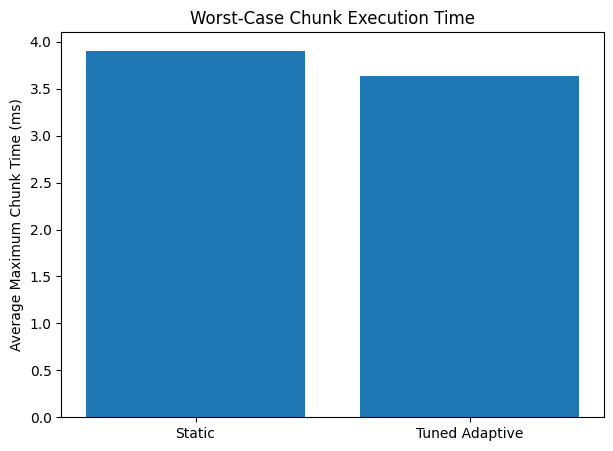

In [16]:
methods = ["Static", "Tuned Adaptive"]

max_time = [
    static_trial_summary["max_chunk_time_ms"].mean(),
    tuned_summary["max_chunk_time_ms"].mean()
]

plt.figure(figsize=(7, 5))
plt.bar(methods, max_time)
plt.ylabel("Average Maximum Chunk Time (ms)")
plt.title("Worst-Case Chunk Execution Time")
plt.savefig("../results/worst_case_chunk_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
final_summary = pd.DataFrame({
    "Method": ["Static", "Original Adaptive", "Tuned Adaptive"],
    "Avg Runtime (ms)": [
        123.454080,
        1459.896040,
        117.358980
    ],
    "Avg Timing Std Dev (ms)": [
        0.603273,
        0.651571,
        0.566584
    ],
    "Avg Max Chunk Time (ms)": [
        3.905400,
        4.555860,
        3.630400
    ]
})

print(final_summary.to_string(index=False))

           Method  Avg Runtime (ms)  Avg Timing Std Dev (ms)  Avg Max Chunk Time (ms)
           Static         123.45408                 0.603273                  3.90540
Original Adaptive        1459.89604                 0.651571                  4.55586
   Tuned Adaptive         117.35898                 0.566584                  3.63040
